In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.colors as mcolors

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [5]:
idir    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/final/'
ds_traj = xr.open_dataset(idir+'dataset_traj.nc')
ds_temp = xr.open_dataset(idir+'dataset_temp.nc')
ds_wave = xr.open_dataset(idir+'dataset_wave.nc')

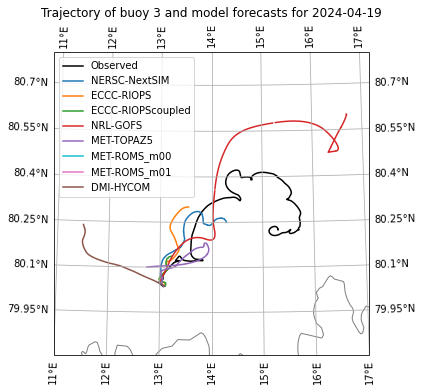

In [8]:
lt_int_sel = ']0_24]'
models_sel = ['NERSC-NextSIM', 'ECCC-RIOPS', 'ECCC-RIOPScoupled', 'NRL-GOFS','MET-TOPAZ5', 'MET-ROMS_m00', 'MET-ROMS_m01', 'DMI-HYCOM']
colors = {
    'NERSC-NextSIM': 'tab:blue',
    'ECCC-RIOPS': 'tab:orange',
    'ECCC-RIOPScoupled': 'tab:green',
    'NRL-GOFS': 'tab:red',
    'MET-TOPAZ5': 'tab:purple',
    'MET-ROMS_m00': 'tab:cyan',
    'MET-ROMS_m01': 'tab:pink',
    'DMI-HYCOM': 'tab:brown'
}

centr_lon = 14
dlon = 3
centr_lat = 80.3
dlat = 1
projection = ccrs.LambertConformal(central_longitude=centr_lon, central_latitude=centr_lat)

fig = plt.figure(figsize=(13, 6))
ax_map = fig.add_axes([0.05, 0.15, 0.9, 0.7], projection=projection)
ax_map.set_extent([centr_lon - dlon, centr_lon + dlon, centr_lat - dlat/2, centr_lat + dlat/2], crs=ccrs.PlateCarree())
ax_map.add_feature(cf.COASTLINE, alpha=0.5)
ax_map.add_feature(cf.BORDERS, alpha=0.5)

buoy_nr = 3
buoy_data = dataset.sel(tr_nr = buoy_nr)
target_date = '2024-04-19'

start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1)
end = start + pd.DateOffset(days=8)
# Plot observed buoy trajectory
ax_map.plot(buoy_data['lon_obs'].sel(time_ds=slice(start,end)), buoy_data['lat_obs'].sel(time_ds=slice(start,end)), 'k-', label='Observed', transform=ccrs.PlateCarree())

# Plot model trajectories
for model_name in models_sel:
    color = colors.get(model_name, 'black')
    for k in range(8):
        lt_int_sel_k = dataset['lt_int'].values[k]
        start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1) + pd.DateOffset(days=k)
        end = start + pd.DateOffset(days=1)
        lon_sim = buoy_data['lon_sim'].sel(model=model_name, time_ds=slice(start, end), lt_int=lt_int_sel_k)
        lat_sim = buoy_data['lat_sim'].sel(model=model_name, time_ds=slice(start, end), lt_int=lt_int_sel_k)
        ax_map.plot(lon_sim, lat_sim, color=color, label=model_name if k == 0 else "", transform=ccrs.PlateCarree())

ax_map.set_title(f'Trajectory of buoy {buoy_nr} and model forecasts for {target_date}')
ax_map.legend(loc='upper left')
ax_map.gridlines(draw_labels=True, x_inline=False, y_inline=False)
plt.show()